[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap06/cap06_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 6 Inspeção Industrial e Análise de Documentos

🚧 **Capítulo em desenvolvimento**

O conteúdo deste capítulo encontra-se em fase de elaboração e será disponibilizado em versão futura, incluindo exercícios práticos, estudos de caso, desafios de programação e aplicações integradas.

---

Na **Parte I — Processamento Digital de Imagens (PDI)**, foram estudadas técnicas para transformação e aprimoramento de imagens, como operações morfológicas, filtragem espacial, convoluções, limiarização, segmentação e processamento no domínio da frequência.

A **Parte II — Visão Computacional (VC)** amplia esse escopo ao tratar da interpretação automática do conteúdo visual, envolvendo a extração de informações, o reconhecimento de padrões e a tomada de decisões a partir de imagens.

Este capítulo apresenta essa transição por meio de duas aplicações representativas:

1. **Inspeção Industrial Automatizada**, voltada ao controle de qualidade e à detecção de defeitos em linhas de produção;
2. **Análise Automatizada de Documentos**, aplicada ao processamento de formulários, avaliações e outros documentos estruturados por meio de sistemas de reconhecimento óptico de marcas (*Optical Mark Recognition* – OMR).

Essas aplicações integram técnicas de detecção de estruturas geométricas, extração de descritores invariantes, reconhecimento de padrões e classificação de objetos, constituindo a base de diversos sistemas modernos de inspeção visual e automação.

---

## 6.1 Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

* Aplicar técnicas de **alinhamento automático de documentos** utilizando a Transformada de Hough;
* **Detectar e segmentar elementos de interesse** com base em propriedades geométricas e descritores invariantes;
* **Extrair informações estruturadas** por meio da análise de padrões espaciais;
* **Implementar sistemas de reconhecimento óptico de marcas** (OMR) para correção automatizada de avaliações e formulários;
* **Avaliar a robustez de algoritmos** frente a ruídos, variações de iluminação e distorções geométricas;
* **Desenvolver soluções de Visão Computacional** aplicadas à inspeção industrial e à análise automatizada de documentos.

---

Este capítulo marca a transição do **Processamento Digital de Imagens**, voltado à transformação de imagens, para a **Visão Computacional**, cujo objetivo é interpretar o conteúdo visual e utilizá-lo na tomada de decisões automatizadas.

## 6.2 Configuração do Ambiente

Os exemplos deste capítulo utilizam bibliotecas amplamente empregadas em
Processamento Digital de Imagens e Visão Computacional. O bloco abaixo
instala os pacotes necessários; em ambientes que já os possuam, a execução
pode ser ignorada.

```python
# 6 Instalação das bibliotecas necessárias
!pip install opencv-python scikit-image numpy pdf2image pandas tabulate
```

Além dessas bibliotecas, será utilizado o módulo didático `morph.py`,
desenvolvido para simplificar operações de leitura, visualização e
processamento de imagens ao longo deste livro. O código a seguir verifica
sua disponibilidade, realiza o *download* quando necessário e confirma a
versão carregada.

In [189]:
import os, importlib, urllib.request
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, data, color 

BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

version = getattr(morph, "__version__", "local_file")
print(f"✅ Ambiente pronto. Módulo 'morph' carregado (versão: {version}).")

✅ Ambiente pronto. Módulo 'morph' carregado (versão: 1.1.2).


## 6.1 Bases de Imagens para Experimentação

Os exemplos desta parte do livro utilizam, sempre que possível, documentos digitalizados, folhas de respostas, códigos de barras, *QR Codes* e outras imagens provenientes de aplicações reais. Para facilitar a reprodução dos experimentos, também são empregadas imagens públicas amplamente utilizadas no ensino e na pesquisa em Visão Computacional.

### 6.1.1 Imagens Públicas com `skimage.data`

A biblioteca `skimage.data` disponibiliza uma coleção de imagens de referência frequentemente utilizada em PDI-VC. O conjunto inclui fotografias, documentos digitalizados, padrões sintéticos e outros exemplos adequados para segmentação, extração de contornos, análise geométrica e reconhecimento de padrões.

A Tabela [Tabela 6.1](#tbl-skimage-data) apresenta algumas das principais imagens dessa coleção, enquanto a  [Figura fig-skimage-data](#fig-skimage-data) ilustra exemplos representativos. Neste capítulo, destacam-se as imagens `page()` e `text()`, particularmente adequadas para experimentos de OCR (*Optical Character Recognition*), OMR (*Optical Mark Recognition*) e análise documental.

### 6.1.2 Imagens Reais com OpenCV

Embora as imagens do `skimage.data` sejam adequadas para demonstrações e validação de algoritmos, aplicações reais normalmente utilizam imagens obtidas por digitalização, câmeras ou outros dispositivos de aquisição.

Para esses casos, a biblioteca OpenCV (`cv2`) oferece funções para leitura de imagens, captura de vídeo e acesso a dispositivos de aquisição. Ao longo deste livro, essas funções são encapsuladas pelo módulo didático `morph.py`, por meio de rotinas como `mm.read`, proporcionando uma interface única para manipulação das imagens. Dessa forma, os algoritmos desenvolvidos podem ser aplicados tanto às imagens públicas quanto a documentos e cenas reais, preservando o mesmo fluxo de processamento.

In [190]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados = {
    "Função": [
        "`data.astronaut()`",
        "`data.camera()`",
        "`data.cat()`",
        "`data.chelsea()`",
        "`data.clock()`",
        "`data.coins()`",
        "`data.coffee()`",
        "`data.horse()`",
        "`data.moon()`",
        "`data.page()`",
        "`data.text()`",
        "`data.checkerboard()`",
        "`data.binary_blobs()`"
    ],
    "Descrição": [
        "Fotografia colorida de um astronauta.",
        "Fotografia clássica em tons de cinza amplamente utilizada em PDI.",
        "Fotografia colorida de um gato.",
        "Retrato colorido da gata Chelsea.",
        "Relógio analógico para detecção de formas e contornos.",
        "Conjunto de moedas utilizado em segmentação e *watershed*.",
        "Fotografia colorida de uma xícara de café.",
        "Silhueta binária de um cavalo.",
        "Imagem da Lua em tons de cinza.",
        "Página digitalizada de documento.",
        "Imagem contendo texto impresso para experimentos de OCR.",
        "Padrão xadrez para calibração e transformações geométricas.",
        "Blobs binários sintéticos para estudos de conectividade e morfologia."
    ]
}

df = pd.DataFrame(dados)

Markdown(
    df.to_markdown(
        index=False,
        colalign=("left", "left")
    )
)

**Tabela 6.1:** Principais imagens públicas disponíveis no módulo *skimage.data*.


| Função                | Descrição                                                             |
|:----------------------|:----------------------------------------------------------------------|
| `data.astronaut()`    | Fotografia colorida de um astronauta.                                 |
| `data.camera()`       | Fotografia clássica em tons de cinza amplamente utilizada em PDI.     |
| `data.cat()`          | Fotografia colorida de um gato.                                       |
| `data.chelsea()`      | Retrato colorido da gata Chelsea.                                     |
| `data.clock()`        | Relógio analógico para detecção de formas e contornos.                |
| `data.coins()`        | Conjunto de moedas utilizado em segmentação e *watershed*.            |
| `data.coffee()`       | Fotografia colorida de uma xícara de café.                            |
| `data.horse()`        | Silhueta binária de um cavalo.                                        |
| `data.moon()`         | Imagem da Lua em tons de cinza.                                       |
| `data.page()`         | Página digitalizada de documento.                                     |
| `data.text()`         | Imagem contendo texto impresso para experimentos de OCR.              |
| `data.checkerboard()` | Padrão xadrez para calibração e transformações geométricas.           |
| `data.binary_blobs()` | Blobs binários sintéticos para estudos de conectividade e morfologia. |

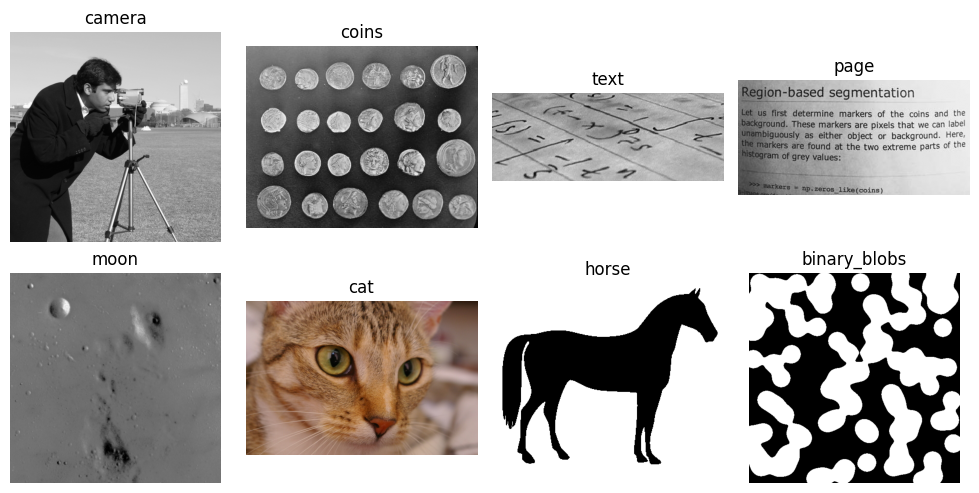

**Figura 6.1:** Algumas imagens públicas disponíveis em *skimage.data*.


In [191]:
import matplotlib.pyplot as plt
from skimage import data

imgs = {
    "camera": data.camera(),
    "coins": data.coins(),
    "text": data.text(),
    "page": data.page(),
    "moon": data.moon(),
    "cat": data.cat(),
    "horse": data.horse(),
    "binary_blobs": data.binary_blobs()
}

fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for a, (nome, img) in zip(ax.ravel(), imgs.items()):
    a.imshow(img, cmap="gray")
    a.set_title(nome)
    a.axis("off")

plt.tight_layout()

## 6.2 Fundamentos de OMR e Inspeção Industrial

O **Reconhecimento Óptico de Marcas** (*Optical Mark Recognition* — OMR) é uma técnica de Visão Computacional destinada à identificação automática de marcações em posições previamente definidas de um formulário. Suas aplicações incluem folhas de respostas, questionários, formulários administrativos e outros documentos estruturados.

Diferentemente do OCR (*Optical Character Recognition*), que reconhece caracteres e palavras, o OMR determina a presença, a ausência ou a intensidade de marcas em regiões previamente conhecidas. Em vez de interpretar texto, explora propriedades geométricas e estatísticas associadas ao preenchimento dessas regiões.

Os sistemas modernos de OMR processam imagens obtidas por *scanners*, câmeras ou dispositivos móveis, automatizando tarefas que anteriormente dependiam de equipamentos especializados.

De forma geral, um sistema de OMR compreende as seguintes etapas:

1. **Aquisição:** conversão do documento físico em formato digital;
2. **Pré-processamento:** correção geométrica, redução de ruídos e binarização;
3. **Localização das regiões de interesse:** identificação das áreas destinadas às marcações;
4. **Análise das marcações:** avaliação do preenchimento das regiões candidatas;
5. **Interpretação:** conversão das marcações em respostas ou dados estruturados.

Esses princípios se estendem naturalmente à **Inspeção Industrial Automatizada**.
Em linhas de produção, o mesmo encadeamento — aquisição, pré-processamento,
segmentação, extração de características e decisão — é empregado para
detectar defeitos superficiais, verificar a integridade de componentes e
medir dimensões com precisão subpixel. A diferença reside no domínio de
aplicação: enquanto o OMR opera sobre documentos com estrutura predefinida,
a inspeção industrial lida com objetos cujas variações geométricas e
radiométricas devem ser modeladas de forma mais flexível.

Nas seções seguintes, ambas as aplicações são desenvolvidas por meio de
projetos práticos que reproduzem etapas típicas de sistemas reais.

---

## 6.3 Projetos Práticos: Construção de um Pipeline de Análise Documental

Os conceitos deste capítulo serão desenvolvidos por meio de projetos que reproduzem etapas típicas de sistemas reais de análise documental, introduzindo técnicas reutilizáveis em aplicações de OCR, OMR, inspeção visual e processamento de formulários.

### 6.3.1 Alinhamento Automático de Documentos (*OCR/OMR Pre-processing*)

A correção de inclinação (*deskew*) é uma etapa fundamental no processamento de documentos. Rotações introduzidas durante a digitalização ou captura comprometem a localização de regiões de interesse e reduzem a precisão das etapas subsequentes.

Neste projeto será desenvolvido um sistema para estimar automaticamente a orientação predominante do documento e corrigir sua inclinação. Para isso, serão empregadas técnicas clássicas de detecção de bordas com o operador de Canny e detecção de retas pela Transformada de Hough. A partir das linhas identificadas, será estimado o ângulo de rotação e aplicada uma transformação afim para produzir uma versão alinhada do documento.

Como formulários e folhas de resposta são frequentemente distribuídos em formato PDF, o *pipeline* inicia-se com a rasterização de cada página, convertendo-a em uma imagem matricial. Neste capítulo, essa etapa será realizada com a biblioteca `pdf2image`, gerando imagens PNG com resolução de 300 DPI (*dots per inch*). A partir delas, poderão ser aplicadas as técnicas de detecção de bordas, Transformada de Hough, segmentação, extração de contornos e reconhecimento automático de padrões estudadas ao longo do capítulo.

[INGESTÃO] Página PDF convertida com sucesso: test01.png
[INGESTÃO] Página PDF convertida com sucesso: test02.png
[INGESTÃO] Página PDF convertida com sucesso: test03.png


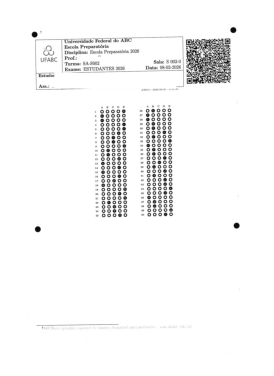

**Figura 6.2:** *Pipeline* de ingestão de documentos: rasterização adaptativa de páginas PDF para matrizes discretas em formato PNG, exibindo a página dois.


In [192]:
import os
import cv2
from pdf2image import convert_from_path
from skimage import data
from morph import mm

# Diretório dos microdados e folhas de respostas do exame institucional
file_path = "dados/provas_qrcode_EP.pdf"

if os.path.exists(file_path):
    # Rasterização das páginas com resolução otimizada de 300 DPI
    pages = convert_from_path(file_path, dpi=300)
    for i, page in enumerate(pages):
        saida = f"test{i+1:02d}.png"
        page.save(saida)
        print(f"[INGESTÃO] Página PDF convertida com sucesso: {saida}")
else:
    print("[AVISO] Arquivo PDF não localizado no path. Ativando fallback via skimage.data.")
    # Injeta matriz de texto pública para garantir a execução contínua do pipeline
    img_fallback = data.text()
    cv2.imwrite("test02.png", img_fallback)
    print("[INGESTÃO] Imagem de fallback estruturada: test02.png")

# Carrega e exibe a imagem rasterizada inicial utilizando o ecossistema morph
img_original = mm.read('test02.png')
mm.show(img_original, figsize=(4, 3))

### 6.3.2 Algoritmo de Retificação de Inclinação (*Deskew*)

A etapa de *deskew* tem como objetivo estimar e corrigir a inclinação global de um documento digitalizado. A  [Figura 6.3](#fig-06-comparativo-pipeline) apresenta o fluxo de processamento, desde a imagem original até o resultado após a correção geométrica.

O procedimento é composto por três etapas principais:

1. detecção de bordas com o operador de Canny;
2. estimação da orientação predominante pela Transformada de Hough;
3. correção da inclinação por meio de uma transformação afim de rotação.

Após a retificação, o documento fica alinhado aos eixos da imagem, favorecendo as etapas subsequentes de segmentação, extração de componentes conexos e reconhecimento de marcas.

### 6.3.3 Modelagem Matemática

Esta seção apresenta os fundamentos matemáticos das três etapas que compõem o processo de retificação: detecção de bordas, estimação da orientação e correção geométrica.

#### 6.3.3.1 Detecção de Bordas

Inicialmente, a imagem é suavizada por um filtro Gaussiano para reduzir ruídos. Os conceitos de filtragem espacial e convolução foram apresentados no **Capítulo 3**. Em seguida, o operador de Canny calcula a magnitude do gradiente,

$$
|\nabla f| =
\sqrt{
\left(\frac{\partial f}{\partial x}\right)^2 +
\left(\frac{\partial f}{\partial y}\right)^2
}.
$$

Após a supressão de não-máximos e a limiarização, obtém-se uma imagem binária contendo as principais bordas do documento.

#### 6.3.3.2 Transformada de Hough

As bordas detectadas são analisadas pela Transformada de Hough Linear. Cada ponto $(x,y)$ contribui para o conjunto de retas descrito por

$$
\rho = x \cos\theta + y \sin\theta.
$$

Os máximos da matriz acumuladora correspondem às estruturas lineares predominantes, como bordas da página, linhas de formulários e linhas de texto.

Para estimar a orientação global, são considerados apenas os ângulos pertencentes ao intervalo $[-45^\circ,45^\circ]$. A mediana desses valores é utilizada como estimativa da inclinação, reduzindo a influência de detecções espúrias.

#### 6.3.3.3 Rotação Afim

Conhecido o ângulo de inclinação, aplica-se uma transformação afim de rotação em torno do centro da imagem. As transformações afins foram estudadas no **Capítulo 2**, juntamente com as operações de translação, escala, cisalhamento e rotação. A função `mm.rotate` implementa essa transformação utilizando interpolação bicúbica para preservar a qualidade visual de contornos e caracteres. 


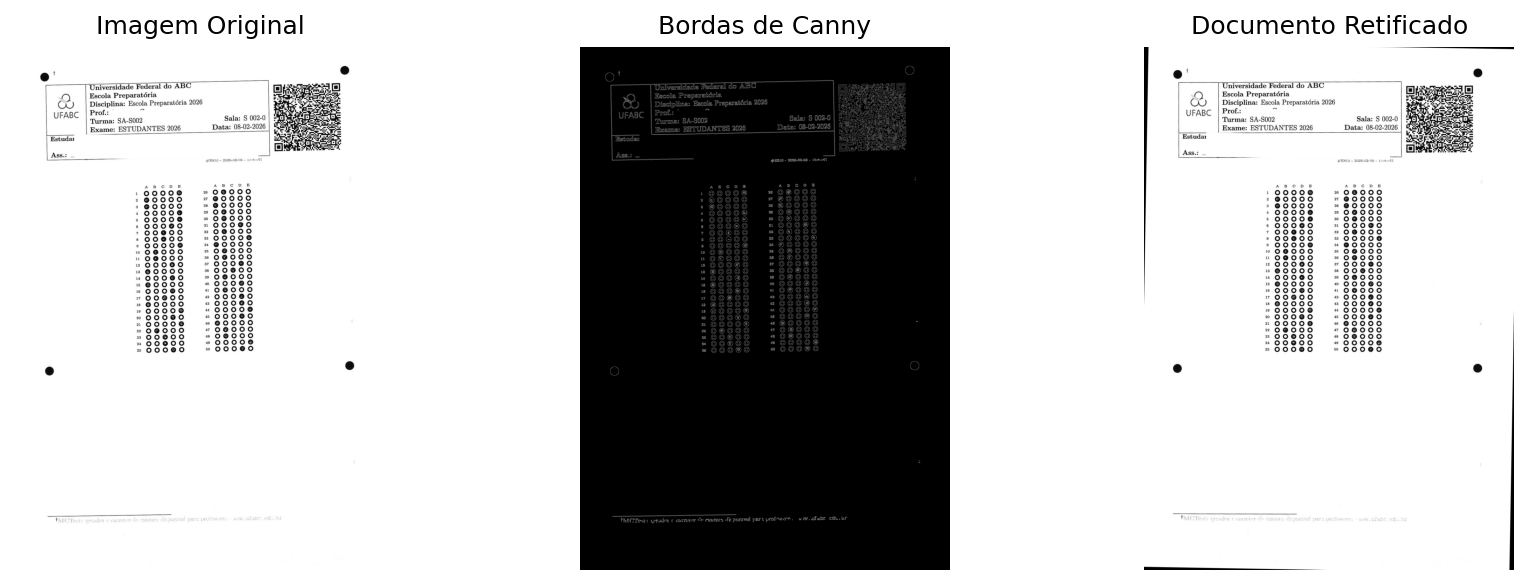

**Figura 6.3:** Pipeline de retificação axial: exibição comparativa entre a entrada rotacionada original, o mapa de gradientes estruturais de Canny e o resultado final alinhado com fundo normalizado em branco.


In [193]:
import cv2
import numpy as np
from morph import mm

def retificar_inclinacao_documento(img):

    gray = mm.gray(img) if img.ndim == 3 else img
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5,5), 0), 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

    if lines is None:
        return edges, img

    angulos = []
    for line in lines:
        angulo = np.rad2deg(line[0][1]) - 90
        if -45 < angulo < 45:
            angulos.append(angulo)

    if not angulos:
        return edges, img

    return edges, mm.rotate(img, np.median(angulos), interp="bicubic")

# Execução do pipeline de deskew
img_edges, img_final = retificar_inclinacao_documento(img_original)

# Exibição múltipla padronizada com o formato nativo do livro
mm.show(
    [img_original, img_edges, img_final],
    titles=["Imagem Original", "Bordas de Canny", "Documento Retificado"],
    cols=3,
    figsize=(12, 4)
)

### 6.3.4 Limitações Práticas

Embora apresente bom desempenho em condições usuais de digitalização, o método depende da existência de estruturas lineares suficientemente definidas para serem detectadas pela Transformada de Hough, como bordas da página, linhas de formulários ou linhas de texto. Sua precisão pode ser reduzida em imagens com baixa resolução, ruído excessivo, sombras intensas ou grandes inclinações. Em geral, documentos digitalizados com resolução próxima de 300 DPI e iluminação homogênea fornecem resultados adequados para aplicações de OCR e OMR.

A implementação apresentada neste capítulo possui finalidade didática, ilustrando os princípios da correção automática de inclinação por meio da detecção de bordas, da Transformada de Hough e da rotação afim. Por utilizar apenas a orientação das estruturas lineares predominantes, o método pode ser aplicado a diferentes tipos de documentos, sem depender de marcadores específicos.

Em sistemas reais de análise documental, entretanto, o alinhamento normalmente utiliza marcadores geométricos previamente conhecidos. No modelo de folha de respostas empregado pelo ecossistema MCTest, por exemplo, são utilizados quatro discos pretos de referência, além das regiões correspondentes ao cabeçalho, ao *QR Code* e aos quadros de respostas. A localização desses elementos permite estimar simultaneamente a rotação, a escala e a translação da folha, tornando o registro menos sensível à quantidade de texto, à ausência de linhas estruturais e às variações de impressão ou digitalização.

Por esse motivo, a abordagem baseada na Transformada de Hough é utilizada neste capítulo para introduzir os fundamentos do problema, enquanto as etapas posteriores adotam o alinhamento por marcadores geométricos, estratégia predominante em sistemas de OMR e análise documental.

## 6.4 Equalização Local de Contraste com CLAHE

A qualidade da segmentação depende diretamente do contraste da imagem de entrada. Em documentos digitalizados, variações de iluminação, sombras, regiões superexpostas e diferenças de tonalidade do papel dificultam a separação entre primeiro plano e fundo por meio de um limiar global.

Uma estratégia amplamente utilizada para compensar essas variações consiste em aplicar a técnica **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*), apresentada no **Capítulo 4**. Diferentemente da equalização global de histograma, o CLAHE divide a imagem em pequenas regiões (*tiles*) e equaliza cada uma individualmente, limitando a amplificação do contraste para evitar o realce excessivo do ruído.

A Figura [Figura 6.4](#fig-06-clahe-page) ilustra esse procedimento utilizando a imagem `page()` da biblioteca `skimage.data`, frequentemente empregada em experimentos de OCR e análise documental. A limiarização de Otsu é aplicada antes e depois do CLAHE, permitindo comparar diretamente os resultados.

Embora aumente o contraste local entre texto e fundo, o CLAHE não corrige variações de iluminação de baixa frequência, como gradientes de luminosidade ao longo da página. Em determinadas situações, essas variações podem até ser realçadas, comprometendo a limiarização global subsequente. Nesses casos, recomenda-se realizar previamente uma normalização do fundo — por exemplo, dividindo a imagem por uma versão suavizada de si mesma —, de modo a uniformizar a iluminação antes da equalização local e da binarização por Otsu.

No projeto de retificação apresentado na seção anterior, a folha de respostas foi digitalizada em condições controladas, tornando suficiente a aplicação direta da limiarização. Em aplicações reais, entretanto, documentos são frequentemente capturados por *scanners* ou câmeras de dispositivos móveis, sob iluminação não uniforme. Nessas situações, a combinação de normalização do fundo, CLAHE e limiarização produz segmentações mais robustas, beneficiando as etapas subsequentes do pipeline de Visão Computacional.

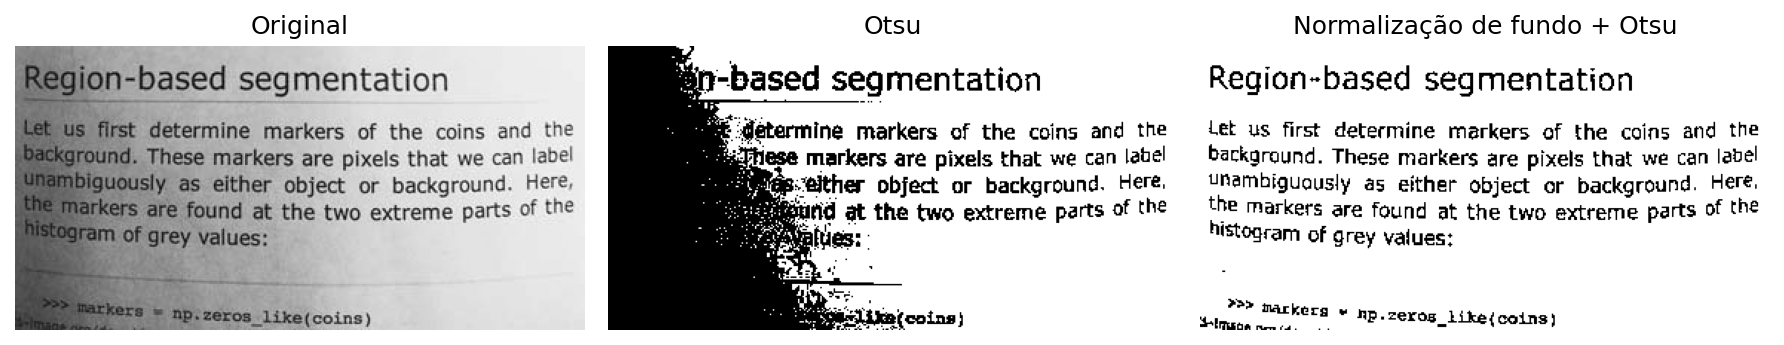

**Figura 6.4:** Correção de iluminação não-uniforme antes da limiarização por Otsu.


In [194]:
import cv2
from skimage import data
from morph import mm

img = data.page()  # ou
# img = mm.gray(img_final)  # com imagem da folha de prova

img_otsu = mm.threshold(img)

# Normalização de fundo: divide a imagem pelo seu próprio "borrão" (fundo estimado)
# sigma maior = remove variações de iluminação mais largas (sombra, gradiente de luz)
bg = cv2.GaussianBlur(img, (0, 0), sigmaX=25)
img_norm = cv2.divide(img, bg, scale=255)
img_norm_otsu = mm.threshold(img_norm)

mm.show(
    [img, img_otsu, img_norm_otsu],
    titles=["Original", "Otsu", "Normalização de fundo + Otsu"],
    cols=3,
    figsize=(12, 4)
)

### 6.4.1 Detecção de Bordas e Contornos

A localização precisa das regiões de interesse é uma etapa fundamental em sistemas de OMR. No modelo de folha de respostas utilizado neste capítulo, o cabeçalho e o quadro de respostas estão contidos em um retângulo virtual delimitado por quatro discos pretos posicionados nos cantos. A identificação desses marcadores permite localizar a região de interesse e corrigir distorções geométricas introduzidas durante a aquisição da imagem.

O procedimento adotado é composto por cinco etapas. Inicialmente, aplica-se um **fechamento morfológico** (dilatação seguida de erosão), operação estudada no **Capítulo 3**, utilizando um elemento estruturante em disco (`mm.sedisk(33)`). Essa operação preserva os discos de referência e reduz pequenas descontinuidades, tornando-os mais homogêneos. Em seguida, a imagem é invertida (`mm.neg`), de modo que os discos passem a corresponder a componentes claros sobre fundo escuro.

Na sequência, aplica-se a operação `mm.edgeoff` (**Capítulo 4**), que remove componentes conectados à borda da imagem, eliminando artefatos como sombras de digitalização, marcas de corte e outros objetos espúrios presentes nas margens. Os componentes remanescentes são então analisados por meio de seus contornos, sendo filtrados por propriedades geométricas, como área e circularidade, para selecionar apenas os quatro discos de referência.

Por fim, os centros desses discos são ordenados espacialmente (superior esquerdo, superior direito, inferior esquerdo e inferior direito) e utilizados como pontos de controle em uma transformação de perspectiva (*perspective warp*). Essa transformação retifica a imagem, produzindo uma representação alinhada e com dimensões conhecidas para as etapas subsequentes de segmentação e reconhecimento.

A Figura [Figura 6.5](#fig-06-deteccao-marcadores) apresenta as principais etapas desse *pipeline*, desde o processamento morfológico até a imagem retificada.

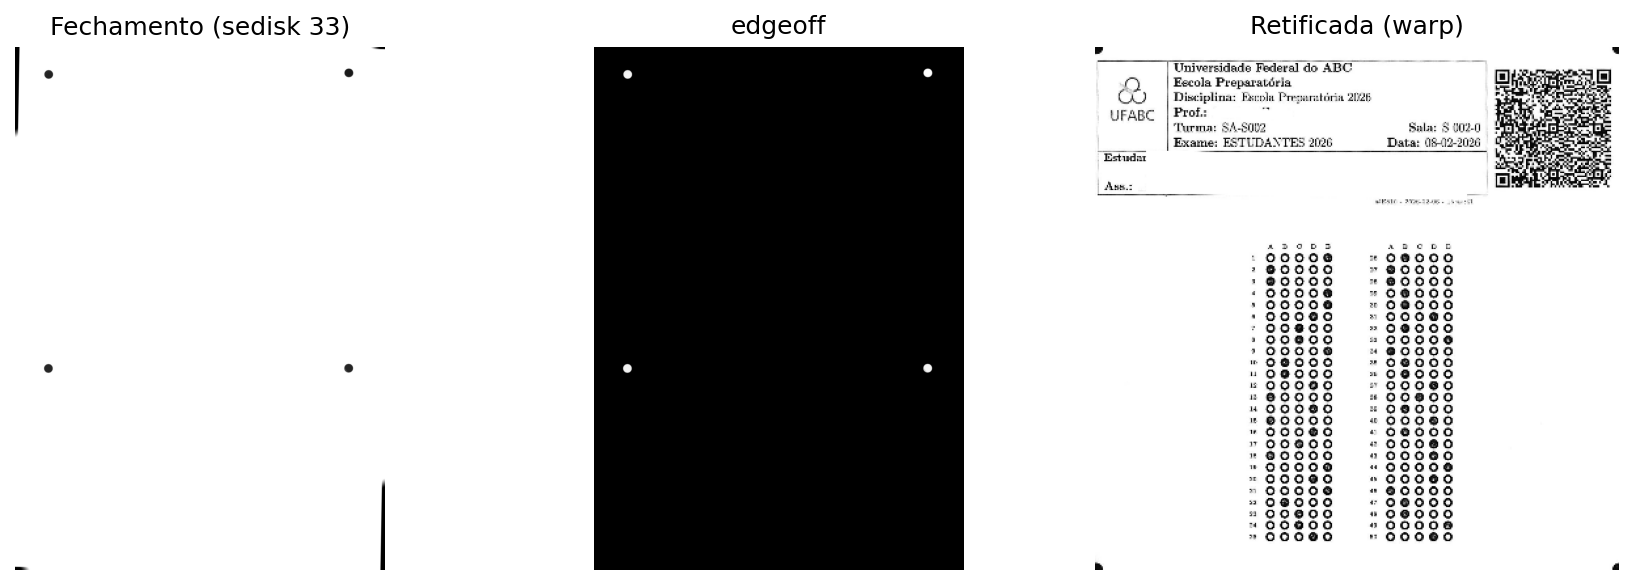

**Figura 6.5:** Detecção dos discos marcadores, extração de contornos e retificação por transformação de perspectiva.


In [195]:
import cv2
import numpy as np
from morph import mm

# img: imagem em escala de cinza da folha de prova
img = mm.gray(img_final)

# 1. Fechamento morfológico: preserva os discos escuros, removento tudo menor que o disco
img_close = mm.close(img, mm.sedisk(41))

# 2. Inversão: discos escuros tornam-se componentes claros sobre fundo escuro
img_neg = mm.neg(img_close)

# 3. Remove componentes conectados que tocam a borda da imagem
img_edgeoff = mm.edgeoff(img_neg)

# 4. Extração dos contornos externos
contornos, _ = cv2.findContours(img_edgeoff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. Filtragem por área e circularidade, mantendo apenas os 4 discos
centros = []
for c in contornos:
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)
    if area < 50 or perimetro == 0:
        continue
    circularidade = 4 * np.pi * area / (perimetro ** 2)
    if circularidade > 0.6:
        M = cv2.moments(c)
        cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]
        centros.append((cx, cy))

assert len(centros) == 4, f"Esperado 4 discos, encontrado {len(centros)}"

# 6. Ordenação dos centros: superior-esquerdo, superior-direito, inferior-esquerdo, inferior-direito
pts = np.array(centros, dtype=np.float32)
soma = pts.sum(axis=1)
diff = pts[:, 0] - pts[:, 1]
tl = pts[np.argmin(soma)]
br = pts[np.argmax(soma)]
tr = pts[np.argmax(diff)]
bl = pts[np.argmin(diff)]
pts_ordenados = np.array([tl, tr, bl, br], dtype=np.float32)

# 7. Retificação por transformação de perspectiva (warp)
largura, altura = 400, 400
destino = np.array(
    [[0, 0], [largura, 0], [0, altura], [largura, altura]], dtype=np.float32
)
M_persp = cv2.getPerspectiveTransform(pts_ordenados, destino)
img_retificada = cv2.warpPerspective(img, M_persp, (largura, altura))

mm.show(
    [img_close, img_edgeoff, img_retificada],
    titles=["Fechamento (sedisk 33)", "edgeoff", "Retificada (warp)"],
    cols=3,
    figsize=(12, 4)
)

### 6.4.2 Isolamento, Segmentação e Decodificação do *QRCode*

Após a retificação geométrica da folha de respostas, realiza-se a detecção e a decodificação do *QRCode* presente no formulário. Esse marcador armazena informações utilizadas pelo sistema de OMR (*Optical Mark Recognition*), como a identificação do aluno, o código da prova e o gabarito oficial. O procedimento é composto por três etapas: pré-processamento morfológico da imagem, isolamento da região do *QRCode* e decodificação do conteúdo.

Inicialmente, a imagem retificada em escala de cinza é binarizada por meio da operação `mm.threshold`. Em seguida, aplica-se uma **abertura morfológica** (erosão seguida de dilatação), estudada no **Capítulo 3**, utilizando um elemento estruturante quadrado de pequenas dimensões (`mm.sebox(2)`). Essa operação elimina pequenos ruídos e suaviza imperfeições sem comprometer a estrutura do marcador. Por fim, a imagem é invertida (`mm.neg`), de modo que o *QRCode* passe a constituir um componente claro sobre fundo escuro, facilitando a extração de contornos.

A localização do *QRCode* é realizada por meio da identificação dos contornos externos da imagem binarizada. Entre os componentes detectados, seleciona-se aquele cuja geometria apresenta formato aproximadamente quadrado e maior área, descartando outros elementos impressos da folha. A região correspondente é então expandida por uma pequena margem de segurança, garantindo que todo o marcador seja preservado no recorte.

O *QRCode* é extraído diretamente da imagem retificada original em escala de cinza, preservando sua qualidade radiométrica. Como essa região normalmente possui dimensões reduzidas, aplica-se um redimensionamento com interpolação cúbica antes da etapa de leitura, aumentando a resolução espacial e favorecendo a identificação dos módulos do código. A decodificação é então realizada por meio do detector de *QRCode* do OpenCV (`cv2.QRCodeDetector`), produzindo a sequência de caracteres originalmente codificada no marcador.

A Figura [Figura 6.6](#fig-06-processamento-qrcode) apresenta o fluxo completo de processamento, desde o pré-processamento morfológico até a extração das informações armazenadas no *QRCode*.

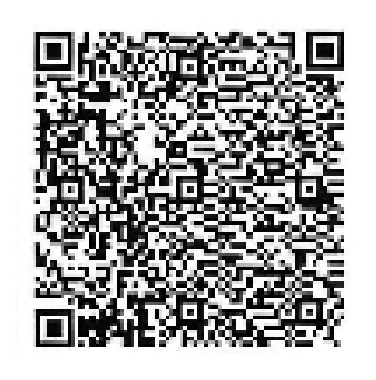

**Figura 6.6:** Pipeline de processamento do *QRCode*: limiarização, abertura morfológica, extração do maior quadro e decodificação digital.


QR Code decodificado com sucesso: 
325a356b71367266556955646b7233454149624a694f417730...


In [196]:
import cv2
import numpy as np
from morph import mm

# f: imagem retificada convertida para o tipo correto de 8 bits (0–255)
f = img_retificada.astype('uint8')

# 1. Limiarização: conversão da imagem em tons de cinza para binária
f_thresh = mm.threshold(f)

# 2. Abertura morfológica: elimina pequenos ruídos e suaviza o contorno dos blocos
f_open = mm.open(f_thresh, mm.sebox(2))

# 3. Inversão morfológica: módulos escuros tornam-se componentes claros sobre fundo escuro
f_inv = mm.neg(f_open)

# 4. Conversão segura para uint8 com escala 0–255
img_uint8 = (f_inv.astype(np.uint8) * 255) if f_inv.max() == 1 else f_inv.astype(np.uint8)

# 5. Detecção de contornos externos
contornos, _ = cv2.findContours(img_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contornos:
    raise ValueError("Nenhum contorno encontrado. Verifique o limiar ou a imagem de entrada.")

# 6. Filtragem pelo maior contorno com proporção aproximadamente quadrada
#    (aspect ratio entre 0.7 e 1.3 descarta retângulos alongados da folha)
def is_square_like(contorno, tol=0.3):
    x, y, w, h = cv2.boundingRect(contorno)
    ratio = w / h if h > 0 else 0
    return (1 - tol) <= ratio <= (1 + tol)

candidatos = [c for c in contornos if is_square_like(c)]

if not candidatos:
    raise ValueError(
        "Nenhum contorno quadrado encontrado. "
        "Verifique se o QR Code está presente na imagem ou ajuste a tolerância."
    )

# Seleciona o maior candidato quadrado por área de bounding box
maior_contorno = max(candidatos, key=lambda c: cv2.boundingRect(c)[2] * cv2.boundingRect(c)[3])
x, y, w, h = cv2.boundingRect(maior_contorno)

# 7. Expansão da bounding box com margem de segurança (evita truncamento do QR Code)
margem = 5
h_img, w_img = img_uint8.shape[:2]
x1 = max(x - margem, 0)
y1 = max(y - margem, 0)
x2 = min(x + w + margem, w_img)
y2 = min(y + h + margem, h_img)

# 8. Recorte da região de interesse a partir da imagem original (nítida, em cinza)
img_qrcode_final = img_retificada[y1:y2, x1:x2]

# 9. Ampliação para resolução mínima de decodificação (400 px no lado maior)
#    cv2.QRCodeDetector requer módulos com ao menos 3–4 px de largura para decodificar
#    com segurança; imagens menores que ~400 px tendem a falhar.
lado = max(img_qrcode_final.shape[:2])
escala = max(400 / lado, 1.0)
img_para_leitura = cv2.resize(
    img_qrcode_final, None,
    fx=escala, fy=escala,
    interpolation=cv2.INTER_CUBIC
)

# 10. Inicialização do detector nativo de QR Code do OpenCV
detector = cv2.QRCodeDetector()

# 11. Detecção geométrica e decodificação dos dados textuais
dados, pontos, qrcode_reto = detector.detectAndDecode(img_para_leitura)

# Exibição do recorte original (antes do zoom, para não distorcer a figura)
mm.show(img_qrcode_final)

# Validação e saída dos metadados extraídos
if dados:
    print(f"QR Code decodificado com sucesso: \n{dados[:50]}...")
else:
    raise ValueError(
        "Falha na decodificação do QR Code. "
        "Verifique o limiar, as margens da região ou a qualidade da imagem."
    )

### 6.4.3 Exercício

repetir processo anterior parecido para o pdf com codigo de barras `dados\provas_barcode.pdf`...

### 6.4.4 Decodificação de Código de Barras

O *QR Code* é uma variante bidimensional de código de barras, capaz de
armazenar centenas de caracteres em uma área compacta. Sistemas mais
simples, entretanto, ainda utilizam **códigos de barras lineares** (1D),
amplamente presentes em embalagens, documentos fiscais e etiquetas
logísticas. A decodificação desses símbolos segue o mesmo princípio
do *pipeline* anterior — aquisição, pré-processamento e leitura —, mas
utiliza a biblioteca `pyzbar`, que suporta dezenas de simbologia s,
incluindo EAN-13, Code 128 e QR Code.

A Figura [Figura 6.7](#fig-06-barcode-decode) exibe a imagem do código de barras carregada
e o resultado da decodificação impresso abaixo.

In [197]:
!pip install pyzbar

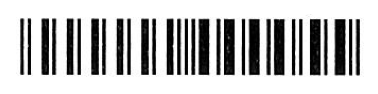

**Figura 6.7:** Decodificação de código de barras linear com `pyzbar`: imagem de entrada e dados extraídos.


Código de barras decodificado com sucesso:
0000000000055


In [198]:
from pyzbar.pyzbar import decode
from morph import mm

image = mm.read('dados/old/barcode.png')
mm.show(image)

barcodes = decode(image)

if barcodes:
    dados = barcodes[0].data.decode("utf-8")
    print(f"Código de barras decodificado com sucesso:\n{dados}")
else:
    raise ValueError(
        "Falha na decodificação do código de barras. "
        "Verifique o contraste, a resolução ou a qualidade da imagem."
    )

### 6.4.5 Usar as Implementações do MCTest

O **MCTest** é um sistema de código aberto para criação, distribuição e correção automatizada de avaliações, desenvolvido na UFABC. Seu módulo de Visão Computacional, concentrado no arquivo `CVMCTest.py`, implementa o mesmo *pipeline* descrito nas seções anteriores — retificação por perspectiva, isolamento do *QR Code* e leitura das bolhas — em uma forma diretamente utilizável em produção. O código-fonte e a documentação estão disponíveis em [github.com/fzampirolli/mctest](https://github.com/fzampirolli/mctest) e em [vision.ufabc.edu.br](http://vision.ufabc.edu.br).

#### 6.4.5.1 Obtenção e Preparação do Módulo

O arquivo `CVMCTest.py` pertence ao ecossistema Django do MCTest e contém importações de modelos e configurações do *framework* que não existem fora do ambiente Web. Para utilizá-lo em um *notebook*, basta baixá-lo com `requests` e remover essas dependências com `sed`, tornando o módulo autocontido.

In [199]:
import requests
CVMCTest = requests.get("https://raw.githubusercontent.com/fzampirolli/mctest/master/exam/CVMCTest.py")
with open('CVMCTest.py', 'w') as writefile:
    writefile.write(CVMCTest.text)

In [200]:
# instalar se ainda nao estiver
if False:
  !pip install PyPDF2 > /dev/null
  !pip install bcrypt > /dev/null
  !pip install scikit-image > /dev/null
  !pip show pyarrow > /dev/null
  !pip install --upgrade cudf-cu12 > /dev/null

Cada linha do `sed` abaixo elimina um grupo de importações incompatíveis — modelos de banco de dados (`exam`, `student`, `topic`), configurações do servidor (`mctest`) e o próprio *framework* (`django`). Sem essa limpeza, qualquer `import CVMCTest` lançaria `ModuleNotFoundError` imediatamente.

In [201]:
# remove linhas with "form django.", ...
!sed --in-place '/from django./d' CVMCTest.py
!sed --in-place '/from exam./d' CVMCTest.py
!sed --in-place '/from mctest./d' CVMCTest.py
!sed --in-place '/from student./d' CVMCTest.py
!sed --in-place '/from topic./d' CVMCTest.py
!sed --in-place '/from .models import VariationExam/d' CVMCTest.py

#### 6.4.5.2 Decodificação do QR Code com `CVMCTest`

Com o módulo preparado, a função `decodeQRcode` aplica internamente as mesmas etapas de binarização, zoom e detecção apresentadas na seção anterior, devolvendo diretamente o dicionário de metadados da prova. O exemplo abaixo utiliza uma imagem já segmentada do *QR Code* — equivalente a `img_qrcode_final` obtido no *pipeline* manual. A Figura [Figura 6.8](#fig-06-mctest-qrcode-seg) exibe essa imagem de entrada, e o resultado impresso confirma que ambas as abordagens produzem o mesmo dicionário de metadados.

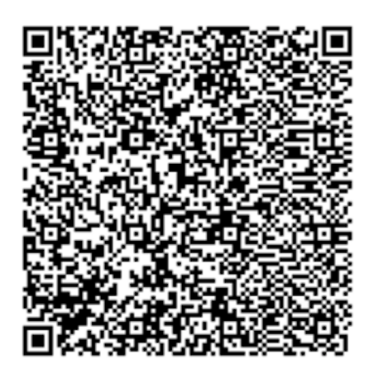

**Figura 6.8:** Imagem segmentada do *QR Code* utilizada como entrada para `CVMCTest.decodeQRcode`.


In [202]:
file = "./dados/old/extra02.qrcodeSeg.png"

image = mm.read(file)
mm.show(image)

In [203]:
import CVMCTest

ss = CVMCTest.cvMCTest.decodeQRcode(image)
ss

{'date': '0',
 'idClassroom': '81',
 'idExam': '103',
 'idStudent': '11000001',
 'term': '2',
 'stylesheet': '1',
 'var1': '5',
 'var2': '0',
 'var3': '0',
 'var4': '0',
 'var5': '0',
 'text': '0',
 'answer': '5',
 'numquest': 5,
 'correct': '',
 'dbtext': '',
 'variations': '23124301',
 'variant': '23234021'}

#### 6.4.5.3 Extração da Área de Respostas

O *pipeline* completo começa pela rasterização do PDF e pela leitura da imagem em escala de cinza, exatamente como na seção de ingestão de documentos. A função `getAnswerArea` localiza os quatro discos de referência, estima a transformação de perspectiva e devolve a região da folha que contém os quadros de marcação, já retificada e com dimensões fixas. A Figura [Figura 6.9](#fig-06-mctest-img-original) exibe a imagem em escala de cinza carregada, e a Figura [Figura 6.10](#fig-06-mctest-answer-area) mostra a área de respostas extraída por `getAnswerArea`.

extra02.qrcode_p0.png
extra02.qrcode_p1.png
extra02.qrcode_p2.png


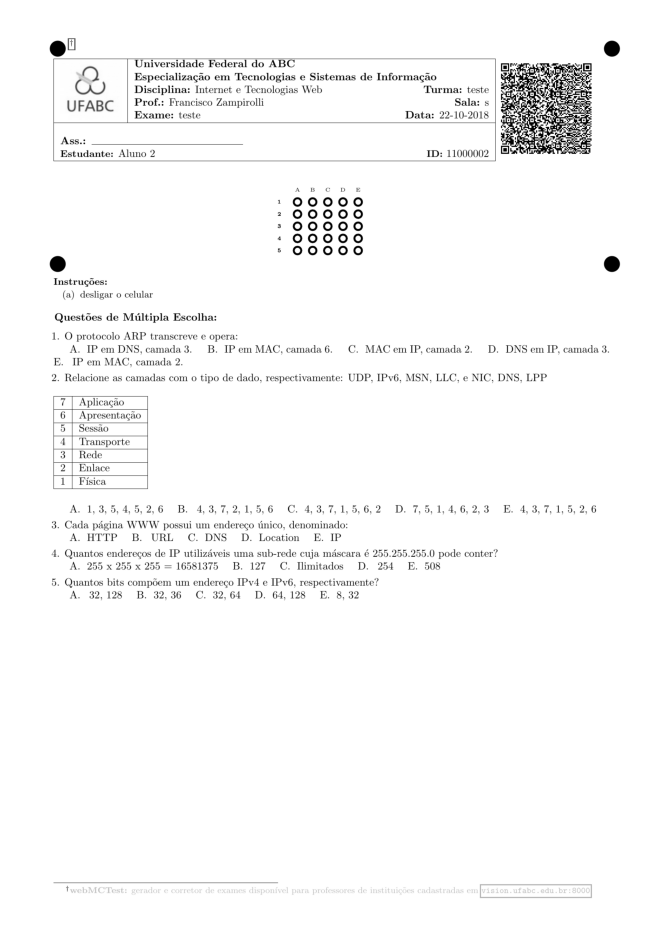

**Figura 6.9:** Imagem da folha de respostas em escala de cinza carregada a partir do PDF rasterizado.


In [204]:
 
 
file = "dados/provas_qrcode.pdf"
pages = convert_from_path(file, 200)  # dpi 100=min 500=max
numPAGES = 0
MYFILES = 'extra02.qrcode'
for page in pages:
  myfile0 = MYFILES + '_p' + str(numPAGES) + '.png'
  page.save(myfile0)
  numPAGES += 1
  print(myfile0)
pages.clear()

img_color = mm.read(myfile0)
img = img0 = mm.gray(img_color)
mm.show(img)

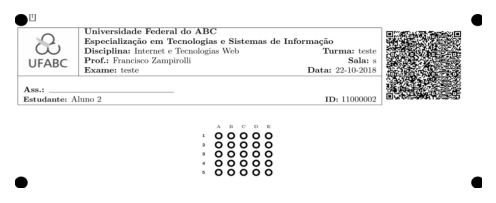

**Figura 6.10:** Área de respostas extraída por `getAnswerArea`: região retificada contendo os quadros de marcação.


In [205]:
import CVMCTest
countPage = 0
img2 = CVMCTest.cvMCTest.getAnswerArea(img, countPage)
mm.show(img2)

**Nota de compatibilidade:** versões recentes do NumPy (≥ 2.0) removeram o alias `np.int0`. Caso `CVMCTest.py` utilize esse tipo, o comando abaixo aplica a correção diretamente no arquivo antes de recarregá-lo:

In [206]:
!sed -i 's/box = np.int0(cv2.boxPoints(rect))/box = cv2.boxPoints(rect).astype(np.intp)/' ~/VSCode/pdi-vc/all/cap06/CVMCTest.py

In [207]:
import importlib
import CVMCTest

importlib.reload(CVMCTest)

<module 'CVMCTest' from '/home/fz/VSCode/pdi-vc/all/cap06/CVMCTest.py'>

#### 6.4.5.4 Segmentação do *QR Code* e Localização dos Quadros

Dentro da área de respostas retificada, o MCTest executa duas operações preparatórias antes de ler as bolhas. A função `segmentQRcode` isola o *QR Code* para uma segunda tentativa de decodificação — útil quando a resolução da imagem completa era insuficiente —, enquanto `getQRCode` devolve o indicador `myFlagArea`, que sinaliza se a área de respostas foi localizada com sucesso, e o dicionário `qr`, que acumulará todas as informações da prova. A Figura [Figura 6](#fig-06-mctest-qrcode-seg2) exibe o *QR Code* isolado dentro da área de respostas.

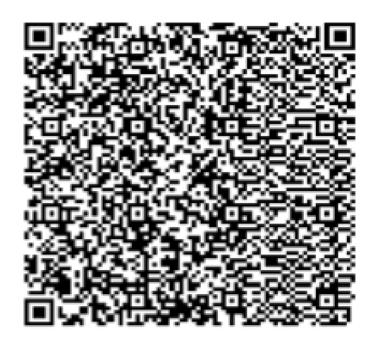

In [208]:
import CVMCTest
imgQR = CVMCTest.cvMCTest.segmentQRcode(img2, countPage)
mm.show(imgQR)

In [209]:
import CVMCTest

ss = CVMCTest.cvMCTest.decodeQRcode(image)
ss

{'date': '0',
 'idClassroom': '81',
 'idExam': '103',
 'idStudent': '11000001',
 'term': '2',
 'stylesheet': '1',
 'var1': '5',
 'var2': '0',
 'var3': '0',
 'var4': '0',
 'var5': '0',
 'text': '0',
 'answer': '5',
 'numquest': 5,
 'correct': '',
 'dbtext': '',
 'variations': '23124301',
 'variant': '23234021'}

A função `findSquares` varre `img2` em busca dos quadros de respostas e devolve uma lista de pares de coordenadas `(p1, p2)` — canto superior esquerdo e inferior direito de cada quadro. A Figura [Figura 6.11](#fig-mctest-img2-full) exibe a área de respostas completa e a Figura [Figura 6.12](#fig-mctest-img2-crop) mostra o recorte inferior, onde os quadros de marcação estão concentrados.

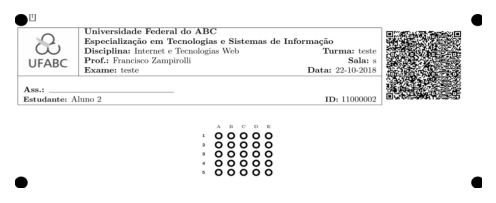

**Figura 6.11:** Área de respostas completa (`img2`) antes da localização dos quadros de marcação.


In [210]:
mm.show(img2)

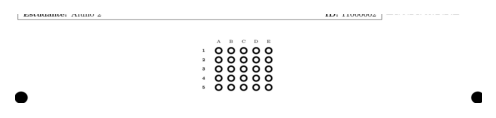

**Figura 6.12:** Recorte inferior da área de respostas, concentrando os quadros de bolhas a serem segmentados.


In [211]:
img3 = img2[220:,:]
mm.show(img3)

In [212]:
myFlagArea, qr = CVMCTest.cvMCTest.getQRCode(img, countPage)
myFlagArea, qr

(True,
 {'date': '0',
  'idClassroom': '81',
  'idExam': '103',
  'idStudent': '11000002',
  'term': '2',
  'stylesheet': '1',
  'var1': '5',
  'var2': '0',
  'var3': '0',
  'var4': '0',
  'var5': '0',
  'text': '0',
  'answer': '5',
  'numquest': 5,
  'correct': '',
  'dbtext': '',
  'variations': '22341230',
  'variant': '21510432'})

In [213]:
rectSquares = CVMCTest.cvMCTest.findSquares(qr,img2, countPage)
rectSquares

[[[np.int64(296), np.int64(508)], [np.int64(430), np.int64(674)]]]

#### 6.4.5.5 Leitura Automática das Respostas

Para cada quadro localizado em `rectSquares`, `setColumns` e `setLines` estimam, respectivamente, o número de alternativas por questão e o número de questões, analisando a distribuição espacial das bolhas. Com essas dimensões conhecidas, `segmentAnswers` avalia o grau de preenchimento de cada bolha e classifica a resposta marcada. Por fim, `setAnswarsOneLine` consolida as respostas de todos os quadros em uma única entrada no dicionário `qr`, pronta para comparação com o gabarito oficial recuperado do *QR Code*. A Figura [Figura 6.13](#fig-mctest-answers) exibe o valor final de `qr['answers']` com as respostas lidas automaticamente.

In [214]:
testAnswers = []
if myFlagArea:

  for countSquare in range(len(rectSquares)):
      p1, p2 = rectSquares[countSquare]

      if True:
          imgQi = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
          [NUM_COLUMNS, img] = CVMCTest.cvMCTest.setColumns(imgQi, countPage, countSquare)
          [NUM_LINES, img] = CVMCTest.cvMCTest.setLines(imgQi, countPage, countSquare)
          NUM_RESPOSTAS = NUM_COLUMNS
          NUM_QUESTOES = NUM_LINES

      imgQiNC = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
      testAnswers.append(CVMCTest.cvMCTest.segmentAnswers(
          [imgQi, imgQiNC], countPage, countSquare, NUM_QUESTOES, qr
      ))

  qr = CVMCTest.cvMCTest.setAnswarsOneLine(testAnswers, qr)  # deixa as respostas de cada quadro em uma linha
qr['answers']

'0,0,0,0,0'

**Figura 6.13:** Respostas lidas automaticamente pelo MCTest após segmentação e classificação de todas as bolhas.


## 6.5 Inspeção Industrial Automatizada

A inspeção visual automatizada é uma das aplicações mais consolidadas da
Visão Computacional na indústria. Em linhas de produção de alta velocidade,
câmeras industriais capturam imagens de cada peça ou produto, e algoritmos
de processamento determinam, em milissegundos, se a peça está dentro das
especificações de qualidade. Essa abordagem elimina a variabilidade inerente
à inspeção humana e permite taxas de verificação incompatíveis com operadores
manuais.

Do ponto de vista algorítmico, a detecção de defeitos por subtração de
imagem é uma das estratégias mais diretas: compara-se a imagem capturada
com uma referência livre de defeitos. Regiões com diferença de intensidade
acima de um limiar são classificadas como anomalias. Esse método pressupõe
que as condições de iluminação e o posicionamento do objeto sejam
reprodutíveis entre capturas — requisito atendido em ambientes industriais
controlados, mas que requer atenção em sistemas de campo.

A Figura [Figura 6.14](#fig-industrial-defeito) ilustra essa abordagem com uma imagem
simulada: à esquerda, o produto de referência; ao centro, a versão com
defeito introduzido artificialmente; à direita, a máscara binária resultante
da limiarização da diferença, destacando a região afetada.

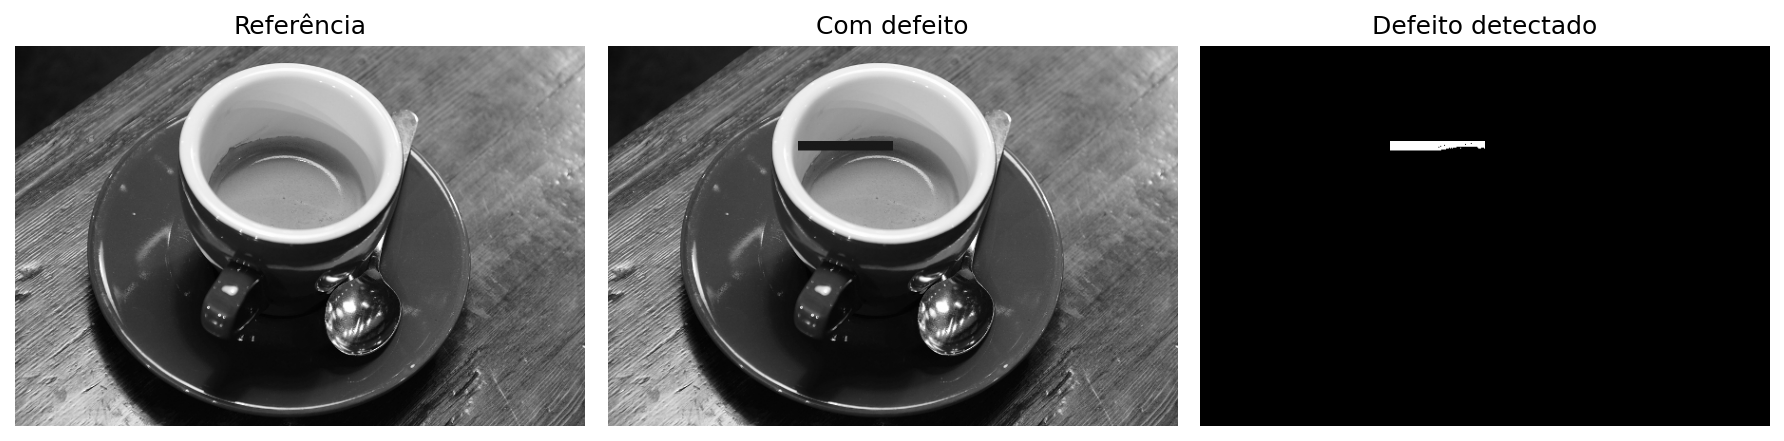

**Figura 6.14:** Detecção de defeito por subtração de imagem: produto de referência, imagem com defeito simulado e máscara de anomalia detectada.


Defeito detectado.


In [215]:
import numpy as np
from skimage import data, color
from morph import mm

# Imagem de referência (produto sem defeito)
product_color = data.coffee()
product_gray = color.rgb2gray(product_color)

# Inserção de defeito simulado: arranhão escuro de 10×100 px
defect_image = np.copy(product_gray)
defect_image[100:110, 200:300] = 0.1

# Detecção por subtração e limiarização
difference = np.abs(product_gray - defect_image)
defect_threshold = 0.15          # ajustável conforme a aplicação
detected_defect = (difference > defect_threshold).astype(np.uint8) * 255

mm.show(
    [product_gray, defect_image, detected_defect],
    titles=["Referência", "Com defeito", "Defeito detectado"],
    cols=3,
    figsize=(12, 4)
)

status = "Defeito detectado." if detected_defect.any() else "Produto conforme."
print(status)

## 6.6 Exercícios Práticos

Os exercícios a seguir ampliam progressivamente os *pipelines* desenvolvidos
neste capítulo, introduzindo requisitos de robustez, detecção de anomalias
e integração sistêmica. Cada exercício indica o valor de pontuação e a
saída esperada, permitindo avaliação objetiva da implementação.

Arquivo: `dados\provas_barcode.pdf`


### 6.6.1 Exercício 1: Validação Robusta contra Ruídos (Valor: 4,0 pontos)

**Contexto:** No Projeto 2, detectamos bolhas apenas pela **circularidade** e **área**. Porém, em documentos com baixa qualidade de scanner, manchas, rasgos ou sujeira podem ter área e circularidade similares às bolhas reais, causando falsos positivos.

**Desafio:** Implemente uma validação adicional baseada nos **Momentos Invariantes de Hu** ($h_1, h_2, \ldots, h_7$). Especificamente:
1. Calcule $h_1$ (primeiro momento invariante) para **uma elipse perfeita** e **um retângulo** de mesma área
2. Compare os valores—eles devem ser significativamente diferentes
3. Use $h_1$ como critério adicional de filtro no Projeto 2: aceitar apenas bolhas cujo $h_1$ se aproxime do valor de uma elipse
4. Teste o novo pipeline em imagens com diferentes níveis de ruído e compare a taxa de falsos positivos

**Saída esperada:** Um gráfico mostrando como a métrica $h_1$ reduz falsos positivos mantendo a detecção de bolhas reais.

---

### 6.6.2 Exercício 2: Detecção de Fraudes e Dupla Marcação (Valor: 6,0 pontos)

**Contexto:** Em avaliações reais, estudiantes frequentemente tentam fazer fraude:
- Marcar **duas alternativas na mesma questão** (indecisão ou tentativa de fraude)
- **Raspar ou apagar** uma marcação (deixando mancha cinza)
- **Marcar fora da bolha** (invalidando a resposta)

**Desafio:** Modifique o Projeto 2 para adicionar **validação de integridade**:
1. Para cada questão, se **duas ou mais alternativas** apresentarem preenchimento acima de $50\%$, marque como **"ANULADA — Dupla Marcação"**
2. Se o preenchimento ficar entre $30\%-50\%$ em qualquer alternativa, marque como **"SUSPEITA — Preenchimento Parcial"** (possível rasura)
3. Se nenhuma alternativa ultrapassar $45\%$, marque como **"BRANCO"**
4. Gere um **relatório detalhado** indicando quais questões têm problemas e o percentual de integridade do formulário

**Saída esperada:** Um relatório estruturado em JSON ou pandas DataFrame mostrando para cada questão: [resposta_lida, confiança, status_integridade].

---

### 6.6.3 Exercício 3: Pipeline Completo de End-to-End (Valor: 10,0 pontos — Desafio)

**Contexto:** Você agora tem os dois projetos funcionando separadamente. O desafio final é **integrá-los em um sistema único e robusto**.

**Desafio:**
1. Crie uma função `processar_prova_completa(caminho_pdf)` que:
   - Converta PDF para imagem (Projeto 1 — setup)
   - Alinhe a página automaticamente (Projeto 1)
   - Detecte e decodifique o QR Code (Projeto 2 — extração de ID)
   - Processe todas as bolhas com validação robusta (Proj 2 + Ex 1)
   - Detecte fraudes e anomalias (Projeto 2 + Ex 2)
   - Retorne um dicionário com: `{id_aluno, id_prova, gabarito_lido, confianca_media, questoes_problema, score_estimado}`

2. Teste em **múltiplas imagens** com variações:
   - Alinhamento perfeito vs. rotacionado ±10°
   - Qualidade de scanner alta vs. baixa
   - Documentos com fraudes vs. legítimos
   - Diferentes formatos de folha de resposta

3. Documente os **casos limites** onde o algoritmo falha e sugira melhorias

**Saída esperada:** Uma classe `ProcessadorProvas` reutilizável, com testes unitários e um notebook mostrando resultados em 5+ casos reais.

---
## 6.7 Próximos Passos

Este capítulo encerrou a construção de um *pipeline* completo de análise
documental — da ingestão do PDF à leitura automática das respostas —,
utilizando operações morfológicas, transformações geométricas, detecção de
contornos e decodificação de marcadores. Esses fundamentos são
transferíveis a qualquer domínio que envolva reconhecimento de padrões em
imagens estruturadas.

Os capítulos seguintes ampliam o escopo para cenas não estruturadas e
aprendizado de representações:

- **Capítulo 7** — Detecção de objetos em cenas complexas: faces, pedestres
  e placas de veículos, com técnicas baseadas em descritores e janelas
  deslizantes.
- **Capítulo 8** — Reconhecimento e *matching* de padrões: busca por
  similaridade visual e correspondência de características entre imagens.
- **Capítulo 9** — Rastreamento em vídeo: estimação de trajetórias e
  associação de detecções ao longo do tempo.
- **Capítulo 10** — Aprendizado profundo para visão: redes convolucionais,
  detecção em tempo real e transferência de aprendizado.